# 🎬 Movie Genre Classification Project

## 📌 Objective
The goal of this project is to develop a machine learning model that can accurately classify movies into one or more genres based on their **plot descriptions**.

## 🛠️ Task Overview
- Utilize **text-based movie descriptions** from the IMDb dataset.
- Clean and preprocess the text data for machine learning.
- Convert raw text into numerical vectors using appropriate **feature extraction techniques** (e.g., TF-IDF).
- Train and evaluate **multiple classifiers** to determine the best model.
- Analyze feature importance and misclassifications for model interpretability.

## 🧠 Machine Learning Goals
- Perform **multi-label classification**, as movies can belong to more than one genre.
- Achieve high performance using metrics like **F1-score**, **Hamming Loss**, and **Accuracy**.

## ✅ Expected Outcome
- A **well-trained model** capable of predicting movie genres from textual descriptions.
- Visual and statistical insights into:
  - Important features (words)
  - Model performance per genre
  - Common misclassification patterns
tions.tions.

## Step 1: Load and Explore the Dataset

The dataset contains movie information for genre classification. The training file includes:
- `ID`
- `TITLE`
- `GENRE`
- `DESCRIPTION`

The test file includes the same format, except without the `GENRE` label.

We'll load the train file using a custom delimiter `:::` and explore its structure.


In [1]:
import pandas as pd

In [2]:
# Load the train data
train_df = pd.read_csv('Genre Classification Dataset/train_data.txt', sep=':::', engine='python', names=["ID", "Title", "Genre", "Description"])

In [3]:
# View shape and first few rows
print("Shape of train data:", train_df.shape)
train_df.head()

Shape of train data: (54214, 4)


,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [4]:
train_df.isnull().sum()

ID             0
Title          0
Genre          0
Description    0
dtype: int64

In [5]:
from collections import Counter

In [6]:
# Count genre occurrences
genre_counter = Counter()
train_df['Genre'].dropna().apply(lambda x: genre_counter.update(x.split(',')))

0        None
1        None
2        None
3        None
4        None
         ... 
54209    None
54210    None
54211    None
54212    None
54213    None
Name: Genre, Length: 54214, dtype: object

In [7]:
# Convert to DataFrame
genre_df = pd.DataFrame(genre_counter.items(), columns=["Genre", "Count"]).sort_values(by="Count", ascending=False)

genre_df.head(10)

,Genre,Count
0,drama,13613
3,documentary,13096
4,comedy,7447
12,short,5073
7,horror,2204
1,thriller,1591
10,action,1315
17,western,1032
6,reality-tv,884
18,family,784


## Step 2: Text Preprocessing

In this step, we clean and preprocess the movie `Description` text for further analysis and model training. 
Key operations include:
- Lowercasing
- Removing punctuation and digits
- Removing stopwords
- Tokenization
- Lemmatization (optional but useful)

We'll use NLTK and regular expressions for text cleaning.


In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

In [9]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\besan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\besan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\besan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [11]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    words = nltk.word_tokenize(text)
    
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return ' '.join(words)

In [12]:
train_df['Clean_Description'] = train_df['Description'].astype(str).apply(preprocess_text)

train_df[['Description', 'Clean_Description']].head()

,Description,Clean_Description
0,Listening in to a conversation between his do...,listening conversation doctor parent yearold o...
1,A brother and sister with a past incestuous r...,brother sister past incestuous relationship cu...
2,As the bus empties the students for their fie...,bus empty student field trip museum natural hi...
3,To help their unemployed father make ends mee...,help unemployed father make end meet edith twi...
4,The film's title refers not only to the un-re...,film title refers unrecovered body ground zero...


## Step 3: Text Vectorization

Now that we have cleaned the movie descriptions, we'll convert the text into numerical features using TF-IDF Vectorizer.
This technique captures both:
- How frequently a word appears in a document (Term Frequency)
- How unique the word is across all documents (Inverse Document Frequency)


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # You can increase max_features if needed

# Fit and transform on cleaned descriptions
X = tfidf.fit_transform(train_df['Clean_Description'])

# Convert to dense matrix (optional, only if needed)
X.shape

(54214, 5000)

## Step 4: Genre Encoding

Since each movie can belong to multiple genres (e.g., "Action,Thriller"), we treat this as a multi-label classification task.
We'll use `MultiLabelBinarizer` to convert the list of genres into binary vectors where each column represents one genre.


In [15]:
from sklearn.preprocessing import MultiLabelBinarizer

# Split genre strings into lists
train_df['Genre_List'] = train_df['Genre'].apply(lambda x: x.split(','))

# Initialize the binarizer
mlb = MultiLabelBinarizer()

# Transform genres into binary matrix
y = mlb.fit_transform(train_df['Genre_List'])

# View shape and genres
print("Shape of y:", y.shape)
print("Genre classes:", mlb.classes_)


Shape of y: (54214, 27)
Genre classes: [' action ' ' adult ' ' adventure ' ' animation ' ' biography ' ' comedy '
 ' crime ' ' documentary ' ' drama ' ' family ' ' fantasy ' ' game-show '
 ' history ' ' horror ' ' music ' ' musical ' ' mystery ' ' news '
 ' reality-tv ' ' romance ' ' sci-fi ' ' short ' ' sport ' ' talk-show '
 ' thriller ' ' war ' ' western ']


## Step 5: Model Training and Evaluation

We will train multiple classifiers and compare their performance using appropriate multi-label metrics such as:
- Micro / Macro F1-score
- Hamming Loss
- Accuracy

We'll use `OneVsRestClassifier` for models that are inherently not multi-label aware.


In [16]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, hamming_loss

# Train
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=200))
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_val)

# Evaluate
print("Logistic Regression Hamming Loss:", hamming_loss(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr, target_names=mlb.classes_))


Logistic Regression Hamming Loss: 0.02811849939028764
               precision    recall  f1-score   support

      action        0.68      0.06      0.12       263
       adult        0.82      0.08      0.15       112
   adventure        0.50      0.03      0.05       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.75      0.29      0.41      1443
       crime        1.00      0.01      0.02       107
 documentary        0.81      0.67      0.73      2659
       drama        0.68      0.45      0.54      2697
      family        1.00      0.03      0.06       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.25      0.40        40
     history        0.00      0.00      0.00        45
      horror        0.81      0.32      0.46       431
       music        0.65      0.22      0.32       144
     musical        0.00      0.00      0.00        50
     myste

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb_model = OneVsRestClassifier(MultinomialNB())
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_val)

print("Naive Bayes Hamming Loss:", hamming_loss(y_val, y_pred_nb))
print(classification_report(y_val, y_pred_nb, target_names=mlb.classes_))


Naive Bayes Hamming Loss: 0.031097038198393913
               precision    recall  f1-score   support

      action        0.00      0.00      0.00       263
       adult        0.67      0.02      0.03       112
   adventure        0.33      0.01      0.03       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.73      0.09      0.16      1443
       crime        0.00      0.00      0.00       107
 documentary        0.75      0.62      0.68      2659
       drama        0.65      0.35      0.46      2697
      family        0.00      0.00      0.00       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.03      0.05        40
     history        0.00      0.00      0.00        45
      horror        0.93      0.06      0.12       431
       music        0.69      0.06      0.11       144
     musical        0.00      0.00      0.00        50
     mystery     

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

In [20]:
# Simpler + faster configuration
rf_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=10, max_depth=10, n_jobs=-1))

In [21]:
# Train
rf_model.fit(X_train, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                     n_estimators=10,
                                                     n_jobs=-1))

In [22]:
# Predict and evaluate
y_pred_rf = rf_model.predict(X_val)
print("Random Forest Hamming Loss:", hamming_loss(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf, target_names=mlb.classes_))

Random Forest Hamming Loss: 0.03572197116419195
               precision    recall  f1-score   support

      action        0.00      0.00      0.00       263
       adult        0.00      0.00      0.00       112
   adventure        0.00      0.00      0.00       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.91      0.01      0.03      1443
       crime        0.00      0.00      0.00       107
 documentary        0.88      0.14      0.24      2659
       drama        0.81      0.02      0.03      2697
      family        0.00      0.00      0.00       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.03      0.05        40
     history        0.00      0.00      0.00        45
      horror        0.00      0.00      0.00       431
       music        0.00      0.00      0.00       144
     musical        0.00      0.00      0.00        50
     mystery    

## Step 6: Compare Model Performance

We will compare the performance of Logistic Regression, Naive Bayes, and Random Forest models using the following metrics:
- Hamming Loss (lower is better)
- Micro F1 Score
- Macro F1 Score

This helps us pick the best model for our multi-label genre classification task.


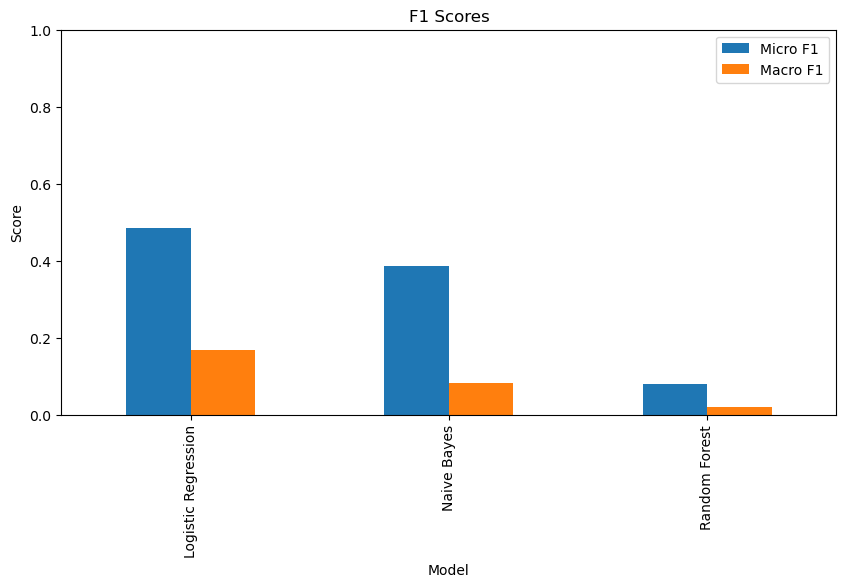

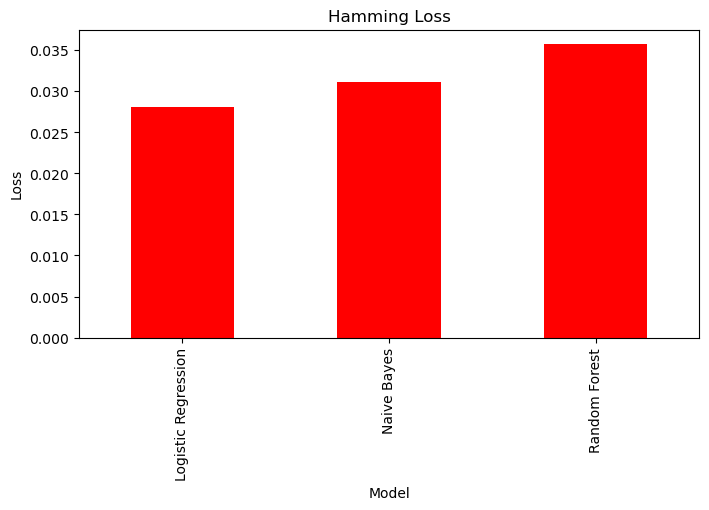

,Model,Hamming Loss,Micro F1,Macro F1
0,Logistic Regression,0.028118,0.485436,0.168723
1,Naive Bayes,0.031097,0.386523,0.082456
2,Random Forest,0.035722,0.078590,0.018601


In [23]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Define a function to evaluate a model
def evaluate_model(name, y_true, y_pred, results):
    hl = hamming_loss(y_true, y_pred)
    micro_f1 = f1_score(y_true, y_pred, average='micro')
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    results.append({
        'Model': name,
        'Hamming Loss': hl,
        'Micro F1': micro_f1,
        'Macro F1': macro_f1
    })

# Collect results
results = []

evaluate_model("Logistic Regression", y_val, y_pred_lr, results)
evaluate_model("Naive Bayes", y_val, y_pred_nb, results)
evaluate_model("Random Forest", y_val, y_pred_rf, results)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Plot
results_df.set_index('Model')[['Micro F1', 'Macro F1']].plot(kind='bar', figsize=(10, 5), ylim=(0, 1), title='F1 Scores')
plt.ylabel('Score')
plt.show()

results_df.set_index('Model')['Hamming Loss'].plot(kind='bar', color='red', title='Hamming Loss', figsize=(8, 4))
plt.ylabel('Loss')
plt.show()

# Display raw results
results_df


In [24]:
import joblib

joblib.dump(lr_model, 'best_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(mlb, 'mlb.pkl')

['mlb.pkl']